In [2]:
# import package
import os
import time
import numpy as np
import hydra
import torch
import subprocess
import logging
import pandas as pd
import shutil
from datetime import datetime
from biotite.sequence.io import fasta
import GPUtil
from typing import Optional, Union, List
from analysis import utils as au
from analysis import metrics
from data import utils as du
from omegaconf import DictConfig, OmegaConf
from openfold.data import data_transforms
import esm
from pathlib import Path
import mdtraj as md
from openfold.np import residue_constants
from tmtools import tm_align
from openfold.utils.superimposition import superimpose
from tqdm import tqdm
import re
import yaml

In [3]:
class DictToObject:
    def __init__(self, dictionary):
        for key, value in dictionary.items():
            if isinstance(value, dict):
                setattr(self, key, DictToObject(value))
            else:
                setattr(self, key, value)

def load_config(file_path):
    with open(file_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [5]:
from EvalRunner_jupyter import EvalRunner
config_dict = load_config("./configs/evaluation.yaml")
conf = DictToObject(config_dict)
EvalModel = EvalRunner(conf)

In [48]:
def graph_by_length(df, key, x_col, y_col, title, y_lim):
    df["length_int"] = (
        df["length"]
        .str.replace("len_", "", regex=False)
        .astype(int)
    )

    df = (
        df
        .groupby("length_int")[key]
        .mean()
        .sort_index()
    )

    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.plot(
        df.index,
        df.values,
        marker="o",
    )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.ylim(y_lim)
    plt.grid(True, alpha=0.3)

# Designability (self-consistency)

## RMSD

In [68]:
default_df = pd.read_csv("../Analysis/RMSD Results/Raw RMSD output/rmsd_default_results.csv")

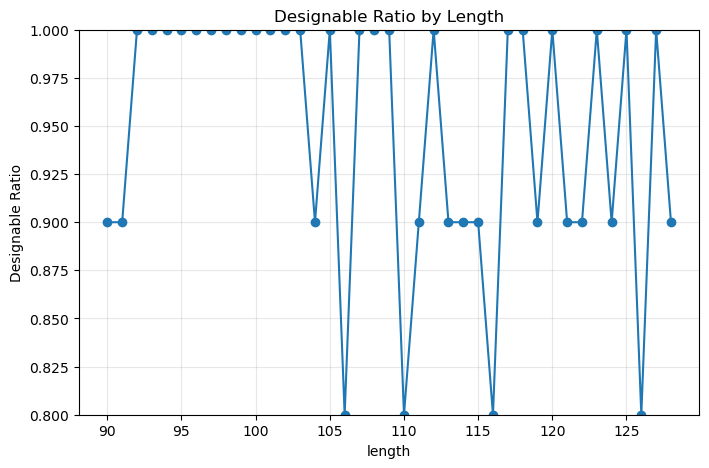

In [ ]:
default_df_design_df = (
    default_df.groupby(["length", "sample"], as_index=False)["bb_rmsd"].min().rename(columns={"bb_rmsd": "min_scRMSD"})
)

default_df_design_df["designable"] = default_df_design_df["min_scRMSD"] < 2.0
graph_by_length(default_df_design_df, "designable", "length", "Designable Ratio", None, (0.8, 1.0))




## pLDDT

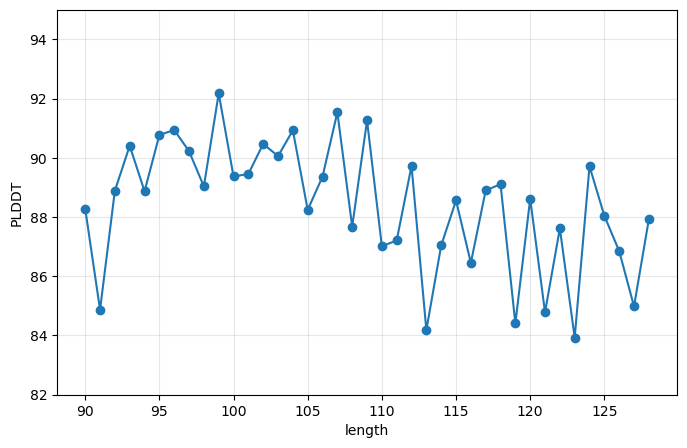

In [72]:
graph_by_length(default_df, "plddt", "length", "PLDDT", None, (82, 95))


# Novelty

In [57]:
default_df_novelty = pd.read_csv("../Analysis/Novelty/Result of designable samples/novelty_default_designable.csv")

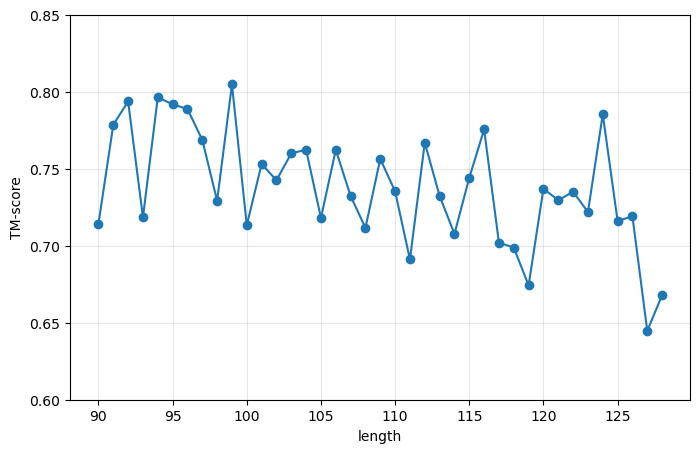

In [73]:
graph_by_length(default_df_novelty, "pdbTM", "length", "TM-score", None, (0.6, 0.85))

# Secondary Structure

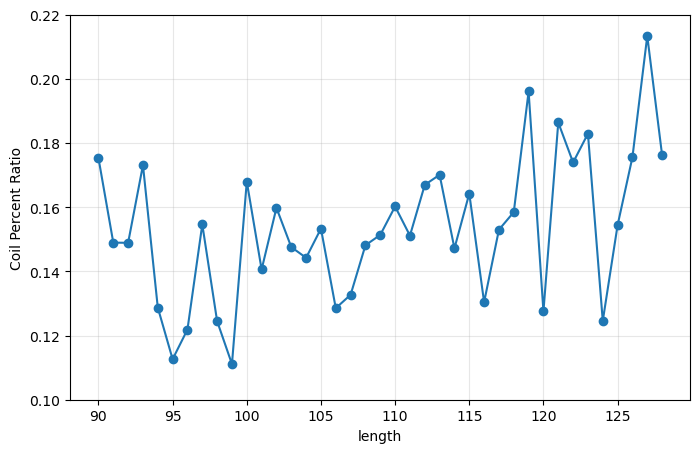

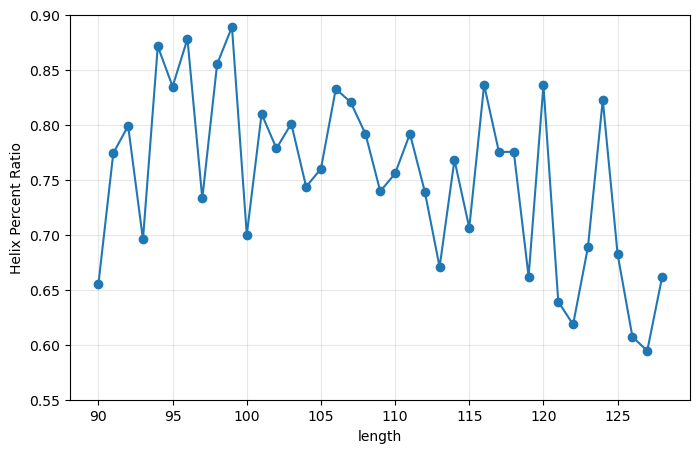

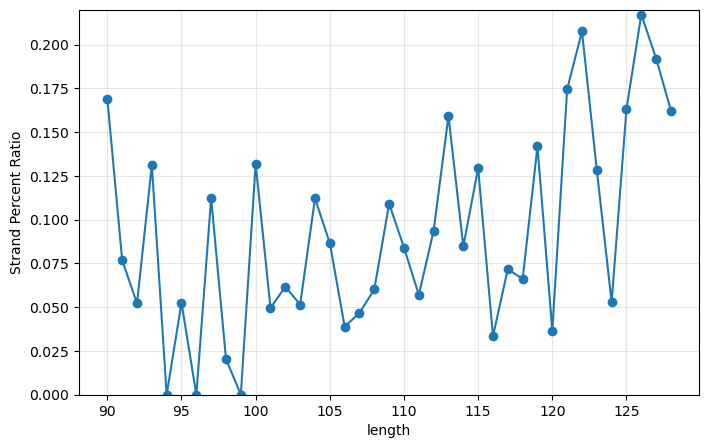

In [67]:
default_df_secondary = pd.read_csv("../Analysis/Secondary structure/Result of designable samples/substructure_default_designable.csv")
graph_by_length(default_df_secondary, "coil_percent", "length", "Coil Percent Ratio", None, (0.1, 0.22))
graph_by_length(default_df_secondary, "helix_percent", "length", "Helix Percent Ratio", None, (0.55, 0.9))
graph_by_length(default_df_secondary, "strand_percent", "length", "Strand Percent Ratio", None, (0.0, 0.22))